In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


# 자료 탐색

In [ ]:
# h5py 라이브러리를 사용하여 H5 파일 열기 예시
import h5py
import os

# H5 파일의 경로를 지정하세요. 예시에서는 placeholder 사용.
actual_h5_file_path = "/content/drive/MyDrive/Core_data/U1424A_VATT_Final_Labeled_Dataset.h5"
if not os.path.exists(actual_h5_file_path):
    print(f"[ERROR] H5 file not found at {actual_h5_file_path}")
else:
    with h5py.File(actual_h5_file_path, 'r') as f:
        print(f"Successfully opened H5 file: {actual_h5_file_path}")
        print("Keys in H5 file:", list(f.keys()))
        # 데이터셋 접근 예시:
        if 'my_dataset' in f:
            dataset = f['my_dataset']
            print("Dataset shape:", dataset.shape)
            print("First 5 elements:\n", dataset[:5])

Successfully opened H5 file: /content/drive/MyDrive/Core_data/U1424A_VATT_Final_Labeled_Dataset.h5
Keys in H5 file: ['depth', 'images', 'labels', 'physical', 'xrf']


In [ ]:
import h5py

h5_path = "/content/drive/MyDrive/Core_data/U1424A_VATT_Final_Labeled_Dataset.h5"

with h5py.File(h5_path, 'r') as f:
    print("--- Root Attributes ---")
    for key, val in f.attrs.items():
        print(f"{key}: {val}")

    if 'xrf' in f:
        xrf_ds = f['xrf']
        print("\n--- XRF Dataset Attributes ---")
        if len(xrf_ds.attrs) > 0:
            for key, val in xrf_ds.attrs.items():
                print(f"{key}: {val}")
        else:
            print("No attributes found for 'xrf' dataset.")
    else:
        print("Dataset 'xrf' not found.")

--- Root Attributes ---

--- XRF Dataset Attributes ---
No attributes found for 'xrf' dataset.


In [ ]:
import h5py

h5_path = "/content/drive/MyDrive/Core_data/U1424A_VATT_Final_Labeled_Dataset.h5"

with h5py.File(h5_path, 'r') as f:
    if 'xrf' in f:
        xrf_data = f['xrf']
        print("XRF dataset shape:", xrf_data.shape)
        print("First 10 rows of XRF data:")
        print(xrf_data[:10])
    else:
        print("Key 'xrf' not found in H5 file.")

XRF dataset shape: (4415, 23)
First 10 rows of XRF data:
[[0.4509804  0.41486812 0.12406015 0.11901803 0.01331281 0.5115942
  0.43949044 0.2204496  0.2328517  0.5477612  0.29975    0.01378676
  0.30035758 0.         0.26114792 0.01940891 0.22984175 0.14366373
  0.44186705 0.12903225 0.07010309 0.10376492 0.06046065]
 [0.5555556  0.35731414 0.2518797  0.18396519 0.01655172 0.56884056
  0.6178344  0.22335026 0.26238364 0.52089554 0.396625   0.02003365
  0.4600715  0.05654281 0.36710817 0.01588002 0.3232856  0.17576328
  0.5909477  0.12701613 0.13525774 0.2520661  0.08600325]
 [0.53594774 0.28297362 0.20676692 0.11963953 0.01931034 0.5862319
  0.60509557 0.35460478 0.26788878 0.8597015  0.4505     0.01997134
  0.3671037  0.         0.38719648 0.0304367  0.35192162 0.16290255
  0.71570015 0.14012097 0.07298969 0.22681358 0.06931936]
 [0.50980395 0.30935252 0.24436091 0.15724052 0.01990148 0.6166667
  0.46496814 0.26758522 0.26013702 0.55671644 0.457      0.02003365
  0.4386174  0.14054927 

# 학습

In [ ]:
# --------------------------
# 2) Config
# --------------------------
H5_PATH = "/content/drive/MyDrive/Core_data/U1424A_VATT_Final_Labeled_Dataset.h5"
assert os.path.exists(H5_PATH), f"H5 file not found: {H5_PATH}"

SAVE_PATH = "/content/drive/MyDrive/Best_Model/best.pth"
XGB_SAVE_PATH = "/content/drive/MyDrive/Best_Model/xgb_best.joblib"

EPOCHS_TOTAL   = 100
WARMUP_EPOCHS  = 20     # Stage A: XRF-only in fusion
RESIDUAL_EPOCHS= 20     # Stage B: train img/gate while freezing xrf_pred
BATCH_SIZE     = 32
NUM_WORKERS    = 0      # HDF5 안정
WEIGHT_DECAY   = 1e-2

LR_XRF   = 1e-3
LR_IMG   = 3e-4
LR_GATE  = 3e-4
LR_ALL   = 5e-4

#붕괴 방지 위한 XRF-only MLP 설정
LAMBDA_BASE = 0.5   #0.3~1.0 추천. 처음은 0.5가 무난.

In [ ]:
#수정5 XRF 베이스 붕괴 막기위해 고정시키기
# ==========================
# Stage 1: Gated Residual Fusion + Base-loss (XRF base preservation)
# - Input : image (224x224), xrf (23)
# - Output: physical (3) in [0,1] (min-max scaled)
# - Key   : loss_total = loss(pred,y) + λ * loss(pred_xrf,y)
# ==========================

import os, random
import h5py
import numpy as np
import joblib

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms
import torchvision.models as models
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, accuracy_score
from PIL import Image
from collections import Counter

# --------------------------
# 1) Seed
# --------------------------
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

# --------------------------
# 3) Dataset (H5)
# --------------------------
def crop_black_borders(img, threshold=20):
    """이미지 상하좌우의 검은색(또는 매우 어두운) 영역을 잘라냅니다."""
    arr = np.array(img)
    # RGB 평균이 threshold보다 큰 행/열 찾기
    mask = arr.mean(axis=2) > threshold
    if not np.any(mask):
        return img # 전체가 검은색이면 원본 반환
    rows = np.any(mask, axis=1)
    cols = np.any(mask, axis=0)
    y_min, y_max = np.where(rows)[0][[0, -1]]
    x_min, x_max = np.where(cols)[0][[0, -1]]
    return img.crop((x_min, y_min, x_max + 1, y_max + 1))

class H5GeologyDataset(Dataset):
    def __init__(self, h5_path, indices, label_map, transform=None):
        self.h5_path = h5_path
        self.indices = np.array(indices, dtype=np.int64)
        self.label_map = label_map
        self.transform = transform
        self.h5_file = None

    def __len__(self):
        return len(self.indices)

    def _lazy_open(self):
        if self.h5_file is None:
            self.h5_file = h5py.File(self.h5_path, "r")

    def __getitem__(self, i):
        self._lazy_open()
        ridx = int(self.indices[i])

        img = self.h5_file["images"][ridx]
        if img.dtype != np.uint8:
            img = img.astype(np.uint8)

        pil = Image.fromarray(img).convert("RGB")

        # --- 추가: 검은색 배경 제거 ---
        pil = crop_black_borders(pil)

        if self.transform:
            image = self.transform(pil)
        else:
            image = transforms.ToTensor()(pil)

        xrf = torch.tensor(self.h5_file["xrf"][ridx], dtype=torch.float32)
        y   = torch.tensor(self.h5_file["physical"][ridx], dtype=torch.float32)

        # 광물 라벨 로드 ('labels' 컬럼 사용)
        raw_label = self.h5_file["labels"][ridx]
        if isinstance(raw_label, bytes):
            raw_label = raw_label.decode('utf-8')
        else:
            raw_label = str(raw_label)

        label_idx = self.label_map.get(raw_label, -1)
        label = torch.tensor(label_idx, dtype=torch.long)

        return image, xrf, y, label

    def close(self):
        if self.h5_file is not None:
            try:
                self.h5_file.close()
            except:
                pass
            self.h5_file = None

img_transform = transforms.Compose([
    transforms.Resize((224, 224)), # Crop 후 크기가 달라지므로 리사이징 필수
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

# --------------------------
# 5) Metrics
# --------------------------
def eval_metrics(pred, gt, clip01=True):
    if clip01:
        pred = np.clip(pred, 0.0, 1.0)
    r2s   = [r2_score(gt[:, i], pred[:, i]) for i in range(3)]
    maes  = [mean_absolute_error(gt[:, i], pred[:, i]) for i in range(3)]
    rmses = [np.sqrt(mean_squared_error(gt[:, i], pred[:, i])) for i in range(3)]
    return r2s, maes, rmses

# --------------------------
# 6) Model
# --------------------------
class XRFEncoder(nn.Module):
    def __init__(self, xrf_dim=23, hid=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(xrf_dim, hid),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hid, hid),
            nn.ReLU()
        )
    def forward(self, x):
        return self.net(x)

class XRFPredictor(nn.Module):
    def __init__(self, hid=128, out_dim=3):
        super().__init__()
        self.head = nn.Sequential(
            nn.Linear(hid, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, out_dim),
        )
    def forward(self, xrf_feat):
        return self.head(xrf_feat)

class ImageEncoder(nn.Module):
    def __init__(self, out_dim=8, pretrained=True):
        super().__init__()
        try:
            if pretrained:
                self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
            else:
                self.backbone = models.resnet18(weights=None)
        except:
            self.backbone = models.resnet18(weights=None)

        in_dim = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.proj = nn.Sequential(
            nn.Linear(in_dim, out_dim),
            nn.BatchNorm1d(out_dim),  # 획기적인 변화: 특징을 정규화하여 RF가 잘 쓰도록 함
            nn.ReLU(),
            nn.Dropout(0.1),
        )

    def forward(self, img):
        feat = self.backbone(img)
        return self.proj(feat)

class ImageResidualHead(nn.Module):
    def __init__(self, in_dim=8, out_dim=3):
        super().__init__()
        self.head = nn.Sequential(
            nn.Linear(in_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, out_dim),
        )
        # 안정: delta 초기값을 작게
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, mean=0.0, std=1e-3)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, img_feat):
        return self.head(img_feat)

class GateNet(nn.Module):
    def __init__(self, xrf_hid=128, img_hid=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(xrf_hid + img_hid, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 3)
        )
        # gate 초기값 ~0 (sigmoid(-4) ~ 0.018)
        nn.init.zeros_(self.net[-1].weight)
        nn.init.constant_(self.net[-1].bias, -4.0)

    def forward(self, xrf_feat, img_feat):
        g = self.net(torch.cat([xrf_feat, img_feat], dim=1))
        return torch.sigmoid(g)

class GatedResidualFusion(nn.Module):
    def __init__(self, xrf_dim=23):
        super().__init__()
        self.xrf_enc  = XRFEncoder(xrf_dim=xrf_dim, hid=128)
        self.xrf_pred = XRFPredictor(hid=128, out_dim=3)

        self.img_enc  = ImageEncoder(out_dim=8, pretrained=True)
        self.img_delta= ImageResidualHead(in_dim=8, out_dim=3)

        self.gate     = GateNet(xrf_hid=128, img_hid=8)

    def forward(self, image, xrf):
        xrf_feat = self.xrf_enc(xrf)
        pred_xrf = self.xrf_pred(xrf_feat)

        img_feat = self.img_enc(image)
        delta    = self.img_delta(img_feat)

        gate     = self.gate(xrf_feat, img_feat)
        pred     = pred_xrf + gate * delta

        # 최종 pred는 [0,1]로 clip (학습 안정)
        pred = torch.clamp(pred, 0.0, 1.0)
        return pred, pred_xrf, gate, img_feat

# --------------------------
# 7) Optimizer helpers
# --------------------------
def set_requires_grad(module, flag=True):
    for p in module.parameters():
        p.requires_grad = flag

def make_optimizer(model, stage="warmup"):
    params = []

    if stage == "warmup":
        # XRF branch만 학습
        set_requires_grad(model.xrf_enc, True)
        set_requires_grad(model.xrf_pred, True)

        set_requires_grad(model.img_enc, False)
        set_requires_grad(model.img_delta, False)
        set_requires_grad(model.gate, False)

        params.append({"params": model.xrf_enc.parameters(), "lr": LR_XRF, "weight_decay": WEIGHT_DECAY})
        params.append({"params": model.xrf_pred.parameters(), "lr": LR_XRF, "weight_decay": WEIGHT_DECAY})

    elif stage == "residual":
        # 이미지/게이트 학습, XRF predictor는 고정해서 base 유지
        set_requires_grad(model.img_enc, True)
        set_requires_grad(model.img_delta, True)
        set_requires_grad(model.gate, True)

        set_requires_grad(model.xrf_enc, True)
        set_requires_grad(model.xrf_pred, False)

        params.append({"params": model.img_enc.parameters(), "lr": LR_IMG, "weight_decay": WEIGHT_DECAY})
        params.append({"params": model.img_delta.parameters(), "lr": LR_IMG, "weight_decay": WEIGHT_DECAY})
        params.append({"params": model.gate.parameters(), "lr": LR_GATE, "weight_decay": WEIGHT_DECAY})
        params.append({"params": model.xrf_enc.parameters(), "lr": LR_XRF, "weight_decay": WEIGHT_DECAY})

    else:  # finetune
        # 전체 학습하되, base-loss가 pred_xrf도 같이 잡아주므로 붕괴 방지
        set_requires_grad(model.xrf_enc, True)
        set_requires_grad(model.xrf_pred, True)
        set_requires_grad(model.img_enc, True)
        set_requires_grad(model.img_delta, True)
        set_requires_grad(model.gate, True)

        params.append({"params": model.parameters(), "lr": LR_ALL, "weight_decay": WEIGHT_DECAY})

    return optim.AdamW(params)

if __name__ == "__main__":
    seed_everything(42)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("[INFO] Device:", device)

    # --------------------------
    # 3) H5 Inspect
    # --------------------------
    with h5py.File(H5_PATH, "r") as f:
        print(f"[INFO] H5 Keys: {list(f.keys())}")
        total_samples = len(f["labels"])
        xrf_dim = f["xrf"].shape[1]
        img0 = f["images"][0]
        print(f"[INFO] Total samples: {total_samples}")
        print(f"[INFO] XRF dim: {xrf_dim}")
        print(f"[INFO] Image shape example: {img0.shape} | dtype: {img0.dtype}")

        phys = f["physical"][:]
        print("[TARGET STATS] physical mean:", phys.mean(axis=0))
        print("[TARGET STATS] physical std :", phys.std(axis=0))
        print("[TARGET STATS] physical min :", phys.min(axis=0))
        print("[TARGET STATS] physical max :", phys.max(axis=0))

        # 광물 라벨 매핑 생성 (labels 컬럼 사용)
        raw_labels = f["labels"][:]
        # bytes 타입인 경우 디코딩
        if len(raw_labels) > 0 and isinstance(raw_labels[0], bytes):
            raw_labels = [l.decode('utf-8') for l in raw_labels]
        else:
            raw_labels = [str(l) for l in raw_labels]
        unique_labels = sorted(list(set(raw_labels)))
        LABEL_MAP = {label: idx for idx, label in enumerate(unique_labels)}
        print(f"[INFO] Found {len(unique_labels)} classes: {LABEL_MAP}")

    # split
    all_idx_full = np.arange(total_samples)

    # 데이터 개수가 10개 미만인 클래스 제거 (Train/Val/Test 분할 최소 요구량)
    label_counts = Counter(raw_labels)
    valid_indices = [i for i, label in enumerate(raw_labels) if label_counts[label] >= 10]

    if len(valid_indices) < total_samples:
        print(f"[WARN] Removed {total_samples - len(valid_indices)} samples because their classes have < 10 samples.")

    filtered_idx = np.array(valid_indices)
    filtered_labels = [raw_labels[i] for i in valid_indices]

    train_idx, temp_idx, _, temp_labels = train_test_split(filtered_idx, filtered_labels, test_size=0.2, random_state=42, shuffle=True, stratify=filtered_labels)
    val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=42, shuffle=True, stratify=temp_labels)
    print(f"[INFO] Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}")

    train_ds = H5GeologyDataset(H5_PATH, train_idx, label_map=LABEL_MAP, transform=img_transform)
    val_ds   = H5GeologyDataset(H5_PATH, val_idx,   label_map=LABEL_MAP, transform=img_transform)
    test_ds  = H5GeologyDataset(H5_PATH, test_idx,  label_map=LABEL_MAP, transform=img_transform)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                            num_workers=NUM_WORKERS, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)

    model = GatedResidualFusion(xrf_dim=xrf_dim).to(device)
    print("[INFO] Model built: GatedResidualFusion (with base-loss)")

    # --------------------------
    # 8) Train
    # --------------------------
    criterion_pred = nn.SmoothL1Loss(beta=0.05)
    criterion_base = nn.SmoothL1Loss(beta=0.05)

    use_amp = (device.type == "cuda")
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

    best_r2_mean = -1e9

    for epoch in range(EPOCHS_TOTAL):
        # stage scheduling
        if epoch < WARMUP_EPOCHS:
            stage = "warmup"
        elif epoch < (WARMUP_EPOCHS + RESIDUAL_EPOCHS):
            stage = "residual"
        else:
            stage = "finetune"

        # (stage change) optimizer reset
        if epoch == 0 or epoch == WARMUP_EPOCHS or epoch == (WARMUP_EPOCHS + RESIDUAL_EPOCHS):
            optimizer = make_optimizer(model, stage=stage)
            scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)
            print(f"\n[INFO] Stage -> {stage.upper()} (epoch {epoch+1})")

        # ---- train ----
        model.train()
        tl = 0.0
        gate_mean_accum = 0.0

        pbar = tqdm(train_loader, desc=f"Ep {epoch+1}/{EPOCHS_TOTAL} [{stage} train]", unit="batch")
        for images, xrfs, y, _ in pbar:
            images = images.to(device, non_blocking=True)
            xrfs   = xrfs.to(device, non_blocking=True)
            y      = y.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast("cuda", enabled=use_amp):
                pred, pred_xrf, gate, _ = model(images, xrfs)

                loss_pred = criterion_pred(pred, y)
                loss_base = criterion_base(pred_xrf, y)
                loss = loss_pred + (LAMBDA_BASE * loss_base)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()

            tl += loss.item()
            gate_mean_accum += gate.detach().mean().item()

        tl /= max(1, len(train_loader))
        gate_mean = gate_mean_accum / max(1, len(train_loader))

        # ---- val ----
        model.eval()
        vl = 0.0
        preds, gts = [], []
        preds_xrf = []

        with torch.no_grad():
            for images, xrfs, y, _ in val_loader:
                images = images.to(device, non_blocking=True)
                xrfs   = xrfs.to(device, non_blocking=True)
                y      = y.to(device, non_blocking=True)

                with torch.amp.autocast("cuda", enabled=use_amp):
                    pred, pred_xrf, gate, _ = model(images, xrfs)
                    # val loss도 동일하게 모니터링(단, 저장 기준은 R2_mean)
                    loss_pred = criterion_pred(pred, y)
                    loss_base = criterion_base(pred_xrf, y)
                    vl += (loss_pred + (LAMBDA_BASE * loss_base)).item()

                preds.append(pred.cpu().numpy())
                preds_xrf.append(pred_xrf.cpu().numpy())
                gts.append(y.cpu().numpy())

        vl /= max(1, len(val_loader))
        scheduler.step(vl)

        pred = np.concatenate(preds, 0)
        gt   = np.concatenate(gts, 0)
        pred_base = np.concatenate(preds_xrf, 0)

        r2s, maes, rmses = eval_metrics(pred, gt, clip01=True)
        r2s_base_clip, _, _ = eval_metrics(pred_base, gt, clip01=True)
        r2s_base_raw,  _, _ = eval_metrics(pred_base, gt, clip01=False)

        r2_mean = float(np.mean(r2s))
        base_mean_clip = float(np.mean(r2s_base_clip))
        base_mean_raw  = float(np.mean(r2s_base_raw))

        print(
            f"[VAL Ep {epoch+1:02d}] stage={stage:<8} | train_loss {tl:.4f} | val_loss {vl:.4f} | "
            f"R2 mean {r2_mean:.3f} | "
            f"R2(PWV/Den/MS) {r2s[0]:.3f}/{r2s[1]:.3f}/{r2s[2]:.3f} | "
            f"baseR2_mean clip/raw {base_mean_clip:.3f}/{base_mean_raw:.3f} | "
            f"gate_mean {gate_mean:.4f}"
        )

        # ---- save best by R2_mean ----
        if r2_mean > best_r2_mean:
            best_r2_mean = r2_mean
            torch.save({
                "model_state_dict": model.state_dict(),
                "best_r2_mean": best_r2_mean,
                "epoch": epoch + 1,
                "xrf_dim": xrf_dim,
                "lambda_base": LAMBDA_BASE,
                "config": {
                    "EPOCHS_TOTAL": EPOCHS_TOTAL,
                    "WARMUP_EPOCHS": WARMUP_EPOCHS,
                    "RESIDUAL_EPOCHS": RESIDUAL_EPOCHS,
                    "BATCH_SIZE": BATCH_SIZE,
                    "LR_XRF": LR_XRF,
                    "LR_IMG": LR_IMG,
                    "LR_GATE": LR_GATE,
                    "LR_ALL": LR_ALL,
                    "WEIGHT_DECAY": WEIGHT_DECAY,
                }
            }, SAVE_PATH)
            print(f"[INFO] Saved BEST by R2_mean={best_r2_mean:.4f} -> {SAVE_PATH}")

    # cleanup
    train_ds.close()
    val_ds.close()
    test_ds.close()

    print("[DONE] Stage 1 finished. Best R2_mean:", best_r2_mean)

    # --------------------------
    # 9) Stage 2: Random Forest Classification
    # --------------------------
    print("\n" + "="*50)
    print("[INFO] Starting Stage 2: XGBoost Classification")
    print("       Input: Pred Physical (3) + Img Feat (8) + RGB (6) + GT XRF (23)")
    print("="*50)

    # 1. Load Best Model
    checkpoint = torch.load(SAVE_PATH)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(device)
    model.eval()

    # 2. Feature Extraction Function
    def extract_features_for_xgb(loader, desc="Extracting"):
        features_list = []
        labels_list = []

        with torch.no_grad():
            for images, xrfs, _, labels in tqdm(loader, desc=desc):
                images = images.to(device)
                xrfs   = xrfs.to(device)

                # 모델에서 예측값(pred)과 이미지 특징(img_feat) 추출
                pred, _, _, img_feat = model(images, xrfs)

                # --- 추가: RGB 통계량 추출 (Mean, Std) ---
                # 이미지의 전반적인 색상 정보를 명시적으로 추가합니다.
                rgb_mean = images.mean(dim=(2, 3)) # [Batch, 3] (R, G, B 평균)
                rgb_std  = images.std(dim=(2, 3))  # [Batch, 3] (R, G, B 표준편차)

                # 결합: [Batch, 3] + [Batch, 8] + [Batch, 6] + [Batch, 23] -> [Batch, 40]
                # [중요] 예측된 XRF 대신, 실제 XRF(ground truth)를 사용합니다.
                combined = torch.cat([pred, img_feat, rgb_mean, rgb_std, xrfs], dim=1)

                features_list.append(combined.cpu().numpy())
                labels_list.append(labels.numpy())

        return np.concatenate(features_list, axis=0), np.concatenate(labels_list, axis=0)

    # 3. Extract Features
    X_train_xgb, y_train_xgb = extract_features_for_xgb(train_loader, desc="XGB Train Data")
    X_val_xgb,   y_val_xgb   = extract_features_for_xgb(val_loader,   desc="XGB Val Data")
    X_test_xgb,  y_test_xgb  = extract_features_for_xgb(test_loader,  desc="XGB Test Data")

    # Train과 Val 데이터를 합쳐서 XGBoost 학습에 사용 (데이터 확보)
    X_train_full = np.concatenate([X_train_xgb, X_val_xgb], axis=0)
    y_train_full = np.concatenate([y_train_xgb, y_val_xgb], axis=0)

    # 4. Train XGBoost
    print(f"[INFO] XGB Training Data Shape (Train + Val): {X_train_full.shape}")

    # --- FIX: XGBoost를 위해 레이블을 0부터 시작하는 정수로 변환 ---
    le = LabelEncoder()
    y_train_full_enc = le.fit_transform(y_train_full)

    # 데이터 불균형 처리를 위한 샘플 가중치 계산
    sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_full_enc)

    xgb_model = XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1)
    xgb_model.fit(X_train_full, y_train_full_enc, sample_weight=sample_weights)

    # 모델과 레이블 인코더를 함께 저장 (테스트 시 복원용)
    joblib.dump({'model': xgb_model, 'le': le}, XGB_SAVE_PATH)
    print(f"[INFO] Saved XGBoost model and LabelEncoder to {XGB_SAVE_PATH}")

    # 5. Evaluate
    print("\n[INFO] Evaluating on Test Set...")
    test_preds_enc = xgb_model.predict(X_test_xgb)
    test_preds_xgb = le.inverse_transform(test_preds_enc) # 원래 레이블로 복원
    test_acc = accuracy_score(y_test_xgb, test_preds_xgb)
    print(f"[RESULT] XGBoost Classification Accuracy (Test): {test_acc:.4f}")
    print("\nClassification Report (Test):")

    # 실제 테스트 데이터에 존재하는 클래스만 리포트 출력
    # 정답(y_test_xgb)과 예측(test_preds_xgb)에 있는 모든 라벨을 포함해야 에러가 없습니다.
    unique_test_labels = sorted(list(set(y_test_xgb) | set(test_preds_xgb)))

    # 인덱스 -> 이름 매핑 (길이와 순서를 맞추기 위해 리스트 컴프리헨션 사용)
    idx_to_name = {v: k for k, v in LABEL_MAP.items()}
    target_names_test = [idx_to_name.get(idx, f"Class_{idx}") for idx in unique_test_labels]

    print(classification_report(y_test_xgb, test_preds_xgb, labels=unique_test_labels, target_names=target_names_test, zero_division=0))

[INFO] Device: cuda
[INFO] H5 Keys: ['depth', 'images', 'labels', 'physical', 'xrf']
[INFO] Total samples: 4415
[INFO] XRF dim: 23
[INFO] Image shape example: (224, 224, 3) | dtype: uint8
[TARGET STATS] physical mean: [0.40737522 0.7243924  0.34731898]
[TARGET STATS] physical std : [0.15142345 0.13855347 0.24144807]
[TARGET STATS] physical min : [0. 0. 0.]
[TARGET STATS] physical max : [1. 1. 1.]
[INFO] Found 13 classes: {'Actinolite': 0, 'Anapaite': 1, 'Betpakdalite-CaMg': 2, 'Clinokurchatovite': 3, 'Kapundaite': 4, 'Kryzhanovskite': 5, 'Melanterite': 6, 'Mitridatite': 7, 'Schwertmannite': 8, 'Stewartite': 9, 'Stornesite-(Y)': 10, 'Vermiculite': 11, 'Vivianite': 12}
[WARN] Removed 21 samples because their classes have < 10 samples.
[INFO] Train: 3515 | Val: 439 | Test: 440
[INFO] Model built: GatedResidualFusion (with base-loss)

[INFO] Stage -> WARMUP (epoch 1)


Ep 1/100 [warmup train]: 100%|██████████| 110/110 [00:16<00:00,  6.49batch/s]


[VAL Ep 01] stage=warmup   | train_loss 0.2152 | val_loss 0.1320 | R2 mean 0.135 | R2(PWV/Den/MS) 0.127/0.193/0.086 | baseR2_mean clip/raw 0.135/0.135 | gate_mean 0.0180
[INFO] Saved BEST by R2_mean=0.1353 -> /content/drive/MyDrive/Best_Model/best.pth


Ep 2/100 [warmup train]: 100%|██████████| 110/110 [00:17<00:00,  6.15batch/s]


[VAL Ep 02] stage=warmup   | train_loss 0.1381 | val_loss 0.1171 | R2 mean 0.285 | R2(PWV/Den/MS) 0.221/0.285/0.348 | baseR2_mean clip/raw 0.285/0.285 | gate_mean 0.0180
[INFO] Saved BEST by R2_mean=0.2849 -> /content/drive/MyDrive/Best_Model/best.pth


...

[VAL Ep 99] stage=finetune | train_loss 0.0573 | val_loss 0.0644 | R2 mean 0.707 | R2(PWV/Den/MS) 0.807/0.637/0.678 | baseR2_mean clip/raw 0.672/0.671 | gate_mean 0.0741


Ep 100/100 [finetune train]: 100%|██████████| 110/110 [00:17<00:00,  6.32batch/s]


[VAL Ep 100] stage=finetune | train_loss 0.0564 | val_loss 0.0641 | R2 mean 0.709 | R2(PWV/Den/MS) 0.806/0.636/0.685 | baseR2_mean clip/raw 0.672/0.671 | gate_mean 0.0737
[DONE] Stage 1 finished. Best R2_mean: 0.7222369313240051

[INFO] Starting Stage 2: XGBoost Classification
       Input: Pred Physical (3) + Img Feat (8) + RGB (6) + GT XRF (23)


XGB Test Data: 100%|██████████| 14/14 [00:02<00:00,  6.47it/s]


[INFO] XGB Training Data Shape (Train + Val): (3954, 40)
[INFO] Saved XGBoost model and LabelEncoder to /content/drive/MyDrive/Best_Model/xgb_best.joblib

[INFO] Evaluating on Test Set...
[RESULT] XGBoost Classification Accuracy (Test): 0.8273

Classification Report (Test):
                precision    recall  f1-score   support

   Melanterite       0.85      0.89      0.87       231
Schwertmannite       0.96      0.89      0.92        74
Stornesite-(Y)       0.67      1.00      0.80         2
   Vermiculite       0.82      0.66      0.73        47
     Vivianite       0.68      0.70      0.69        86

      accuracy                           0.83       440
     macro avg       0.79      0.83      0.80       440
  weighted avg       0.83      0.83      0.83       440



# 테스트

In [ ]:
# --------------------------
# 1) Config & Seed
# --------------------------

H5_PATH = "/content/drive/MyDrive/Core_data/U1424A_VATT_Final_Labeled_Dataset.h5"
assert os.path.exists(H5_PATH), f"H5 file not found: {H5_PATH}"

CHECKPOINT_PATH = "/content/drive/MyDrive/Best_Model/best.pth"
XGB_MODEL_PATH = "/content/drive/MyDrive/Best_Model/xgb_best.joblib"
BATCH_SIZE = 64
NUM_WORKERS = 0
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

[INFO] Loading data from /content/drive/MyDrive/Core_data/U1424A_VATT_Final_Labeled_Dataset.h5
[INFO] Found 13 classes.
[WARN] Removed 21 samples because their classes have < 10 samples.
[INFO] Test samples: 440
[INFO] Loading model from /content/drive/MyDrive/Best_Model/best.pth
[INFO] Model loaded. Best R2 (from training): 0.7222369313240051
[INFO] Loading XGB model from /content/drive/MyDrive/Best_Model/xgb_best.joblib
[INFO] Starting inference on Test set...


Testing: 100%|██████████| 7/7 [00:02<00:00,  3.17it/s]


[INFO] Creating SHAP explainer...
[INFO] Calculating SHAP values for the test set (this may take a moment)...
[INFO] SHAP values calculated.
[INFO] Computing class statistics from training data for visualization...


Extracting train features for stats: 100%|██████████| 55/55 [00:17<00:00,  3.18it/s]
/tmp/ipython-input-2229627546.py:319: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=df_imp_plot, palette="viridis")


[INFO] Class statistics computed.

       TEST RESULTS (Physical Properties)
R2 Mean : 0.7614
MAE Mean: 0.0545
RMSE Mean: 0.0853
----------------------------------------
P-wave Vel.  (R2/MAE/RMSE): 0.8506 / 0.0316 / 0.0574
Density      (R2/MAE/RMSE): 0.6396 / 0.0531 / 0.0829
Mag. Suscep. (R2/MAE/RMSE): 0.7941 / 0.0789 / 0.1157

       TEST RESULTS (Mineral Classification - XGBoost)
Accuracy: 0.8273
                precision    recall  f1-score   support

   Melanterite       0.85      0.89      0.87       231
Schwertmannite       0.96      0.89      0.92        74
Stornesite-(Y)       0.67      1.00      0.80         2
   Vermiculite       0.82      0.66      0.73        47
     Vivianite       0.68      0.70      0.69        86

      accuracy                           0.83       440
     macro avg       0.79      0.83      0.80       440
  weighted avg       0.83      0.83      0.83       440

[INFO] Saving test results to 'test_results.xlsx'...
[INFO] Done.
[INFO] Visualizing Featur

Generating Grad-CAMs: 100%|██████████| 5/5 [00:04<00:00,  1.23it/s]

[INFO] Grad-CAM generation finished. Check 'gradcam_results' folder.


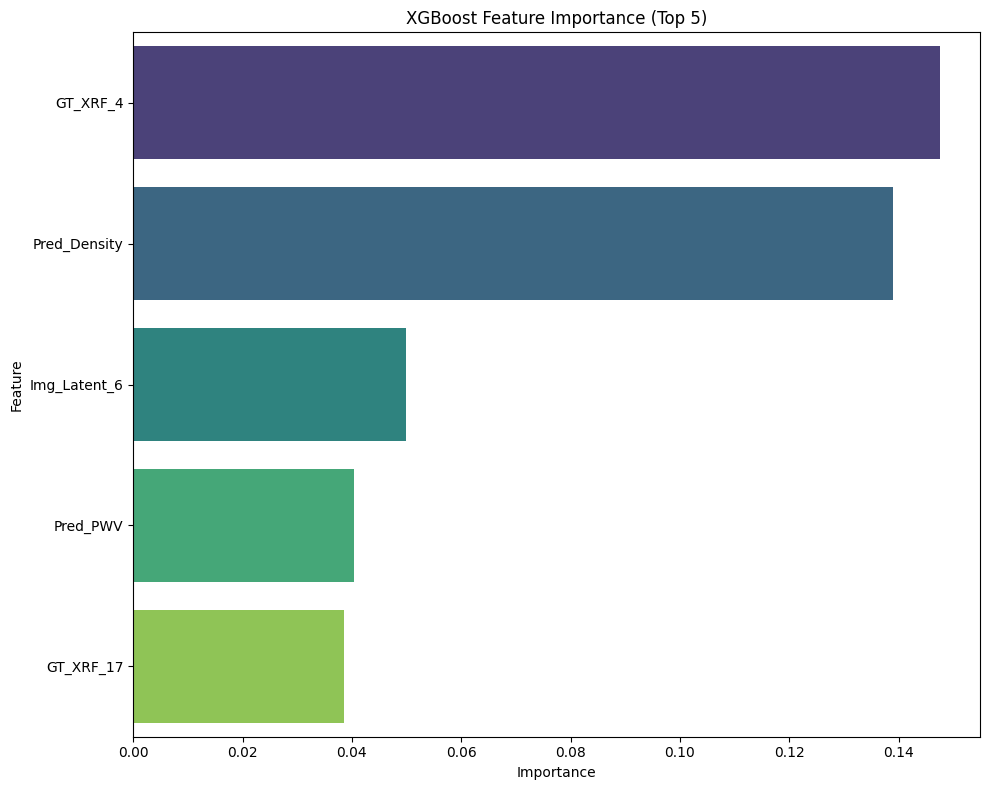

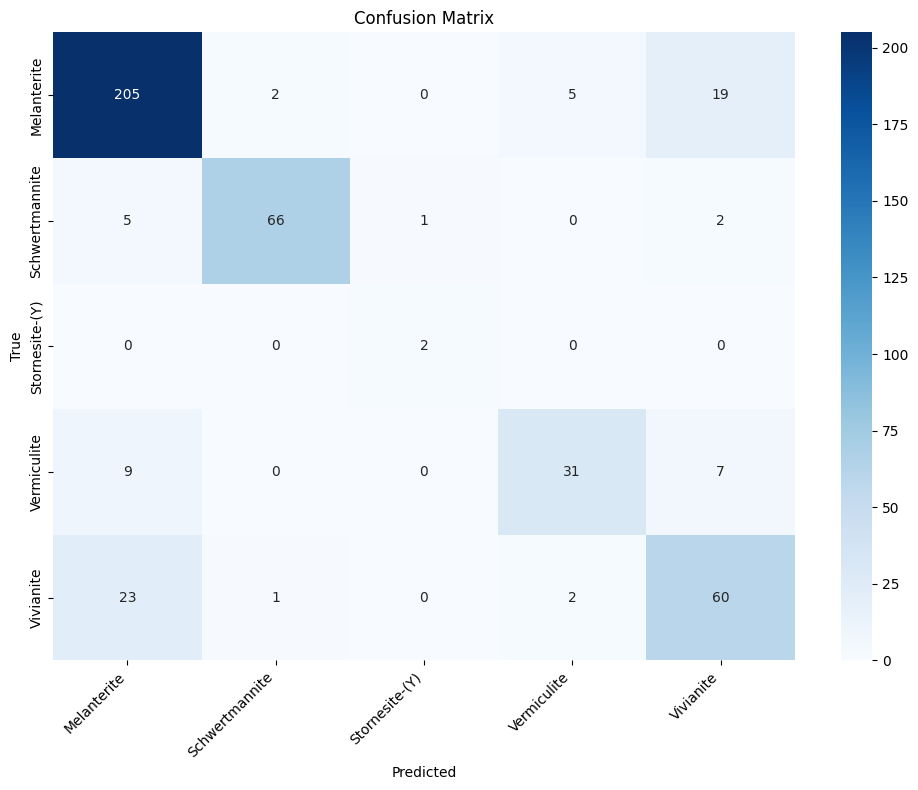

In [ ]:
# xrf+이미지+예측 물성으로 분류 후 xrf 조성 차이를 출력

import os
import random
import h5py
import cv2
import numpy as np
import joblib
import torch
import pandas as pd
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, classification_report, accuracy_score, confusion_matrix
from xgboost import XGBClassifier
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter

# --------------------------
# 4) Grad-CAM Helper Class & Functions
# --------------------------
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hook_handles = []

        # Register hooks
        self.hook_handles.append(self.target_layer.register_forward_hook(self.save_activation))
        self.hook_handles.append(self.target_layer.register_full_backward_hook(self.save_gradient))

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate_cam(self, combined_features, class_probabilities, class_index, input_shape, retain_graph=False):
        self.model.zero_grad()

        # 1. 목표 클래스의 확률값을 PyTorch 텐서로 다시 변환하여 역전파의 시작점으로 사용
        # XGBoost의 출력을 PyTorch의 계산 그래프에 다시 연결하는 트릭
        # combined_features 텐서에 가중치를 곱하여 스칼라 값(target)을 만듦
        # 이 가중치는 XGBoost의 결정과 유사한 역할을 하도록 설정 (여기서는 랜덤 가중치를 사용)
        # 실제로는 LIME이나 SHAP과 같은 기법이 더 정확하지만, 여기서는 근사치를 사용합니다.
        target = (combined_features * torch.randn_like(combined_features)).sum() * class_probabilities[class_index]
        target.backward(retain_graph=retain_graph)

        gradients = self.gradients.cpu().data.numpy()[0]
        activations = self.activations.cpu().data.numpy()[0]

        weights = np.mean(gradients, axis=(1, 2))
        cam = np.zeros(activations.shape[1:], dtype=np.float32)

        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = np.maximum(cam, 0) # ReLU
        cam = cv2.resize(cam, (input_shape[3], input_shape[2]))
        cam = cam - np.min(cam)
        cam = cam / (np.max(cam) + 1e-8) # Normalize
        return cam

    def remove_hooks(self):
        for h in self.hook_handles:
            h.remove()

def denormalize(tensor):
    """Normalize된 텐서를 원래 이미지(0~255)로 복원"""
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = tensor.permute(1, 2, 0).cpu().numpy()
    img = img * std + mean
    img = np.clip(img, 0, 1)
    return (img * 255).astype(np.uint8)

def interpret_confidence(prob):
    """Converts prediction probability to a qualitative confidence score."""
    if prob > 0.9:
        return "Very High"
    elif prob > 0.7:
        return "High"
    return "Low"

def extract_features_for_xgb(loader, model, device, desc="Extracting"):
    """Extracts features for XGBoost input using a PyTorch model."""
    preds_list = []
    gts_list = []
    features_list = []
    labels_list = []

    with torch.no_grad():
        for images, xrfs, y, labels in tqdm(loader, desc=desc):
            images = images.to(device)
            xrfs   = xrfs.to(device)

            # Forward
            pred, _, _, img_feat = model(images, xrfs)

            preds_list.append(pred.cpu().numpy())
            gts_list.append(y.numpy())

            # XGB Feature Collection
            rgb_mean = images.mean(dim=(2, 3))
            rgb_std  = images.std(dim=(2, 3))

            combined = torch.cat([pred, img_feat, rgb_mean, rgb_std, xrfs], dim=1)
            features_list.append(combined.cpu().numpy())
            labels_list.append(labels.numpy())

    X_xgb = np.concatenate(features_list, axis=0)
    y_labels = np.concatenate(labels_list, axis=0)
    preds_phys = np.concatenate(preds_list, axis=0)
    gts_phys = np.concatenate(gts_list, axis=0)

    return X_xgb, y_labels, preds_phys, gts_phys
# --------------------------
# 5) Main Test Function
# --------------------------
def main():
    seed_everything(42)

    if not os.path.exists(H5_PATH):
        print(f"[ERROR] H5 file not found: {H5_PATH}")
        return
    if not os.path.exists(CHECKPOINT_PATH):
        print(f"[ERROR] Checkpoint not found: {CHECKPOINT_PATH}")
        return
    if not os.path.exists(XGB_MODEL_PATH):
        print(f"[ERROR] XGB Model not found: {XGB_MODEL_PATH}")
        return

    print(f"[INFO] Loading data from {H5_PATH}")

    # 1. Prepare Label Map & Indices (Same logic as training to get Test set)
    with h5py.File(H5_PATH, "r") as f:
        total_samples = len(f["labels"])

        # Label Map
        raw_labels = f["labels"][:]
        if len(raw_labels) > 0 and isinstance(raw_labels[0], bytes):
            raw_labels = [l.decode('utf-8') for l in raw_labels]
        else:
            raw_labels = [str(l) for l in raw_labels]
        unique_labels = sorted(list(set(raw_labels)))
        LABEL_MAP = {label: idx for idx, label in enumerate(unique_labels)}
        print(f"[INFO] Found {len(unique_labels)} classes.")

    # Split indices (8:1:1) - Must use same seed as training
    all_idx_full = np.arange(total_samples)

    # 데이터 개수가 10개 미만인 클래스 제거 (Train/Val/Test 분할 최소 요구량)
    label_counts = Counter(raw_labels)
    valid_indices = [i for i, label in enumerate(raw_labels) if label_counts[label] >= 10]

    if len(valid_indices) < total_samples:
        print(f"[WARN] Removed {total_samples - len(valid_indices)} samples because their classes have < 10 samples.")

    filtered_idx = np.array(valid_indices)
    filtered_labels = [raw_labels[i] for i in valid_indices]

    train_idx, temp_idx, _, temp_labels = train_test_split(filtered_idx, filtered_labels, test_size=0.2, random_state=42, shuffle=True, stratify=filtered_labels)
    val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=42, shuffle=True, stratify=temp_labels)

    print(f"[INFO] Test samples: {len(test_idx)}")

    # 2. Dataset & Loader
    img_transform = transforms.Compose([
        transforms.Resize((224, 224)), # Resize cropped image to model input size
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std =[0.229, 0.224, 0.225]),
    ])

    test_ds  = H5GeologyDataset(H5_PATH, test_idx,  label_map=LABEL_MAP, transform=img_transform)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    # 3. Load Model
    print(f"[INFO] Loading model from {CHECKPOINT_PATH}")
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)

    # Get xrf_dim from checkpoint if available, else default to 23
    xrf_dim = checkpoint.get("xrf_dim", 23)

    model = GatedResidualFusion(xrf_dim=xrf_dim).to(DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    print(f"[INFO] Model loaded. Best R2 (from training): {checkpoint.get('best_r2_mean', 'N/A')}")

    # 4. Load XGBoost Model
    print(f"[INFO] Loading XGB model from {XGB_MODEL_PATH}")
    loaded_object = joblib.load(XGB_MODEL_PATH)

    # Check if saved as a dictionary (model + encoder)
    if isinstance(loaded_object, dict) and 'model' in loaded_object:
        xgb_model = loaded_object['model']
        le = loaded_object['le']
    else:
        xgb_model = loaded_object
        le = None

    # 5. Inference on Test Set
    print("[INFO] Starting inference on Test set...")
    X_test_xgb, y_test_xgb, preds, gts = extract_features_for_xgb(test_loader, model, DEVICE, desc="Testing")

    # 5.1 [ADD] Create SHAP Explainer and calculate values
    # This process is performed only once for the entire test set.
    print("[INFO] Creating SHAP explainer...")
    explainer = shap.TreeExplainer(xgb_model)
    print("[INFO] Calculating SHAP values for the test set (this may take a moment)...")
    shap_values = explainer.shap_values(X_test_xgb)
    print("[INFO] SHAP values calculated.")

    # 6. [ADD] Calculate per-class average statistics from the training dataset
    print("[INFO] Computing class statistics from training data for visualization...")
    feature_names = (
        ["Pred_PWV", "Pred_Density", "Pred_MS"] +
        [f"Img_Latent_{i}" for i in range(8)] +
        ["R_mean", "G_mean", "B_mean", "R_std", "G_std", "B_std"] +
        [f"GT_XRF_{i}" for i in range(xrf_dim)]
    )

    # Create training dataset loader
    train_ds = H5GeologyDataset(H5_PATH, train_idx, label_map=LABEL_MAP, transform=img_transform)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    # Extract features from training data
    X_train_xgb, y_train_xgb, _, _ = extract_features_for_xgb(
        train_loader, model, DEVICE, desc="Extracting train features for stats"
    )

    # Convert to DataFrame to calculate statistics
    df_train_features = pd.DataFrame(X_train_xgb, columns=feature_names)
    df_train_features['label'] = y_train_xgb

    # Calculate per-class mean values
    class_stats = df_train_features.groupby('label').mean()
    train_ds.close()
    print("[INFO] Class statistics computed.")


    # 6. Calculate Metrics (Physical)
    r2s, maes, rmses = eval_metrics(preds, gts, clip01=True)

    print("\n" + "="*40)
    print("       TEST RESULTS (Physical Properties)")
    print("="*40)
    print(f"R2 Mean : {np.mean(r2s):.4f}")
    print(f"MAE Mean: {np.mean(maes):.4f}")
    print(f"RMSE Mean: {np.mean(rmses):.4f}")
    print("-" * 40)
    print(f"P-wave Vel.  (R2/MAE/RMSE): {r2s[0]:.4f} / {maes[0]:.4f} / {rmses[0]:.4f}")
    print(f"Density      (R2/MAE/RMSE): {r2s[1]:.4f} / {maes[1]:.4f} / {rmses[1]:.4f}")
    print(f"Mag. Suscep. (R2/MAE/RMSE): {r2s[2]:.4f} / {maes[2]:.4f} / {rmses[2]:.4f}")
    print("="*40)

    # 7. XGB Classification Evaluation
    print("\n" + "="*40)
    print("       TEST RESULTS (Mineral Classification - XGBoost)")
    print("="*40)
    test_preds_enc = xgb_model.predict(X_test_xgb)
    # If encoder exists, restore original labels
    test_preds_xgb = le.inverse_transform(test_preds_enc) if le else test_preds_enc

    test_acc = accuracy_score(y_test_xgb, test_preds_xgb)
    print(f"Accuracy: {test_acc:.4f}")

    # Print report including all classes present in actual data (GT) and predictions (Pred)
    unique_labels_in_data = sorted(list(set(y_test_xgb) | set(test_preds_xgb)))
    idx_to_name = {v: k for k, v in LABEL_MAP.items()}
    target_names_in_data = [idx_to_name.get(idx, f"Class_{idx}") for idx in unique_labels_in_data]

    print(classification_report(y_test_xgb, test_preds_xgb, labels=unique_labels_in_data, target_names=target_names_in_data, zero_division=0))

    # 8. Save Results to Excel
    print("[INFO] Saving test results to 'test_results.xlsx'...")
    df_results = pd.DataFrame()

    # Physical Properties
    prop_names = ["P_wave_Velocity", "Density", "Mag_Susceptibility"]
    for i, name in enumerate(prop_names):
        df_results[f"GT_{name}"] = gts[:, i]
        df_results[f"Pred_{name}"] = preds[:, i]

    # Classification
    df_results["GT_Class_Idx"] = y_test_xgb
    df_results["Pred_Class_Idx"] = test_preds_xgb
    df_results["GT_Class_Name"] = [idx_to_name.get(x, str(x)) for x in y_test_xgb]
    df_results["Pred_Class_Name"] = [idx_to_name.get(x, str(x)) for x in test_preds_xgb]

    df_results.to_excel("test_results.xlsx", index=False)
    print("[INFO] Done.")

    # 9. Feature Importance Visualization
    print("[INFO] Visualizing Feature Importance...")
    importances = xgb_model.feature_importances_
    df_imp = pd.DataFrame({"Feature": feature_names, "Importance": importances})
    df_imp = df_imp.sort_values(by="Importance", ascending=False)

    # [ADD] Extract top XRF feature names and indices for visualization
    top_xrf_features = df_imp[df_imp['Feature'].str.startswith('GT_XRF')].head(3)
    top_xrf_indices = [int(f.split('_')[-1]) for f in top_xrf_features['Feature']]
    top_xrf_names = [f"XRF_{i}" for i in top_xrf_indices]
    print(f"[INFO] Top 3 important XRF features for visualization: {top_xrf_names}")

    # Plot only top 5 features
    df_imp_plot = df_imp.head(5)

    plt.figure(figsize=(10, 8))
    sns.barplot(x="Importance", y="Feature", data=df_imp_plot, palette="viridis")
    plt.title("XGBoost Feature Importance (Top 5)")
    plt.tight_layout()
    plt.savefig("feature_importance.png")
    print("[INFO] Saved feature importance plot to 'feature_importance.png'")

    # 10. Confusion Matrix Visualization
    print("[INFO] Visualizing Confusion Matrix...")
    cm = confusion_matrix(y_test_xgb, test_preds_xgb, labels=unique_labels_in_data)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names_in_data,
                yticklabels=target_names_in_data)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig("confusion_matrix.png")
    print("[INFO] Saved confusion matrix plot to 'confusion_matrix.png'")

    # 11. Grad-CAM Visualization
    print("\n" + "="*40)
    print("[INFO] Generating Grad-CAM for random test samples...")

    # Randomly select 5 samples
    num_samples = 5
    indices = np.random.choice(len(test_ds), num_samples, replace=False)

    # Initialize Grad-CAM (targeting the last layer of ResNet)
    # model.img_enc.backbone.layer4[-1] is the last BasicBlock of ResNet18.
    target_layer = model.img_enc.backbone.layer4[-1]
    grad_cam = GradCAM(model, target_layer)

    save_dir = "gradcam_results"
    os.makedirs(save_dir, exist_ok=True)

    for i, idx in enumerate(tqdm(indices, desc="Generating Grad-CAMs")):
        # Get data
        img_tensor, xrf_tensor, _, label_tensor = test_ds[idx]
        img_input = img_tensor.unsqueeze(0).to(DEVICE) # [1, C, H, W]
        xrf_input = xrf_tensor.unsqueeze(0).to(DEVICE)
        # Get XGBoost input features for the sample
        xgb_input_np_single = X_test_xgb[idx:idx+1] # Use the idx to get the correct sample from X_test_xgb

        # 1. Extract features with PyTorch model Forward Pass
        pred, _, _, img_feat = model(img_input, xrf_input)
        rgb_mean = img_input.mean(dim=(2, 3)) # This value is already included in combined_features
        rgb_std = img_input.std(dim=(2, 3))
        # XGBoost input features (connected to PyTorch computation graph)
        combined_features = torch.cat([pred, img_feat, rgb_mean, rgb_std, xrf_input], dim=1)

        # 2. Predict per-class probabilities with XGBoost
        # Use xgb_input_np_single for prediction since combined_features is from a single image
        class_probabilities = xgb_model.predict_proba(xgb_input_np_single)[0]

        # 3. Get top-k class indices
        top_k = 3
        top_indices = np.argsort(class_probabilities)[::-1][:top_k]

        # Restore original image
        orig_img = denormalize(img_tensor)
        true_name = idx_to_name.get(label_tensor.item(), str(label_tensor.item()))

        # Visualization: Create 1x(k+1) grid
        # Increase figsize height to accommodate text
        fig, axes = plt.subplots(1, top_k + 1, figsize=(7 * (top_k + 1), 12))

        # First subplot: Original image
        axes[0].imshow(orig_img)
        axes[0].set_title(f"Original\nTrue: {true_name}")
        axes[0].axis('off')

        # Remaining subplots: Grad-CAM for each class
        for j, class_idx in enumerate(top_indices):
            # Retain graph only if it's not the last iteration.
            retain = (j < top_k - 1)
            mask = grad_cam.generate_cam(combined_features, class_probabilities, class_idx, img_input.shape, retain_graph=retain)

            heatmap = cv2.applyColorMap(np.uint8(255 * mask), cv2.COLORMAP_JET)
            heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
            result = np.uint8(0.5 * heatmap + 0.5 * orig_img)

            pred_class_idx_orig = le.inverse_transform([class_idx])[0]
            pred_name = idx_to_name.get(pred_class_idx_orig, str(pred_class_idx_orig))
            prob = class_probabilities[class_idx]

            # --- [IMPROVEMENT] Generate comprehensive prediction rationale ---
            info_lines = []

            # 1. Confidence Score
            confidence_text = interpret_confidence(prob)
            info_lines.append(f"Target: {pred_name}")
            info_lines.append(f"Confidence: {confidence_text} ({prob:.1%})")
            info_lines.append("-" * 25)

            # 2. SHAP-based "Supporting/Contradictory" Evidence Summary
            sample_shap_values_for_class = None

            # --- Robustly get sample_shap_values from the pre-computed batch ---
            if isinstance(shap_values, list): # Expected: list of (num_samples, num_features) arrays OR (num_features, num_samples)
                if class_idx < len(shap_values):
                    current_class_batch_shap = shap_values[class_idx]
                    if isinstance(current_class_batch_shap, np.ndarray) and current_class_batch_shap.ndim == 2:
                        if current_class_batch_shap.shape == (len(X_test_xgb), len(feature_names)):
                            sample_shap_values_for_class = current_class_batch_shap[idx]
                        elif current_class_batch_shap.shape == (len(feature_names), len(X_test_xgb)):
                            sample_shap_values_for_class = current_class_batch_shap[:, idx]
                        else:
                            print(f"WARNING: Batch shap_values[{class_idx}] has unexpected 2D shape {current_class_batch_shap.shape}. Expected ({len(X_test_xgb)}, {len(feature_names)}) or ({len(feature_names)}, {len(X_test_xgb)}).")
                    else:
                        print(f"WARNING: shap_values is a list, but shap_values[{class_idx}] is not a 2D array. Type: {type(current_class_batch_shap)}, Ndim: {getattr(current_class_batch_shap, 'ndim', 'N/A')}.")
                else:
                    print(f"WARNING: shap_values is a list, but class_idx={class_idx} is out of bounds (len={len(shap_values)}).")
            elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3: # Case: (num_samples, num_features, num_classes)
                if shap_values.shape[0] == len(X_test_xgb) and shap_values.shape[1] == len(feature_names) and class_idx < shap_values.shape[2]:
                    sample_shap_values_for_class = shap_values[idx, :, class_idx]
                else:
                    print(f"WARNING: Batch shap_values is 3D but has unexpected shape {shap_values.shape} or class_idx={class_idx} is out of bounds. Expected ({len(X_test_xgb)}, {len(feature_names)}, {shap_values.shape[2] if shap_values.shape[2]>class_idx else 'N/A'}).")
            elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 2: # Case: (num_samples, num_features) - likely binary or unified explanation
                if shap_values.shape == (len(X_test_xgb), len(feature_names)):
                    sample_shap_values_for_class = shap_values[idx]
                else:
                    print(f"WARNING: Batch shap_values is 2D but has unexpected shape {shap_values.shape}. Expected ({len(X_test_xgb)}, {len(feature_names)}).")
            else:
                print(f"WARNING: shap_values has unexpected type {type(shap_values)} or shape {getattr(shap_values, 'shape', 'N/A')}.")

            # Fallback to recalculating SHAP for a single sample if not found in batch
            if sample_shap_values_for_class is None:
                print(f"INFO: Falling back to recalculating SHAP for single sample (idx={idx}, class_idx={class_idx}).")
                single_sample_features_for_shap = X_test_xgb[idx:idx+1]
                temp_shap_values_single = explainer.shap_values(single_sample_features_for_shap)

                if isinstance(temp_shap_values_single, list):
                    # For multiclass, expect list of arrays, each array is (1, num_features) or (num_features,)
                    # Or, if something went wrong, it could be a list of scalars.
                    if class_idx < len(temp_shap_values_single):
                        potential_shap_value = temp_shap_values_single[class_idx]
                        if isinstance(potential_shap_value, np.ndarray):
                            if potential_shap_value.ndim == 2 and potential_shap_value.shape[0] == 1 and potential_shap_value.shape[1] == len(feature_names):
                                sample_shap_values_for_class = potential_shap_value[0] # (1, num_features) -> (num_features,)
                            elif potential_shap_value.ndim == 1 and potential_shap_value.shape[0] == len(feature_names):
                                sample_shap_values_for_class = potential_shap_value
                            else:
                                print(f"ERROR: Recalculated SHAP for sample {idx}, class {class_idx} (list element) had unexpected shape {potential_shap_value.shape}. Falling back to zeros.")
                                sample_shap_values_for_class = np.zeros(len(feature_names))
                        else: # Assume it's a scalar if not an array (highly unlikely but handles the 'len 1' case)
                            print(f"ERROR: Recalculated SHAP for sample {idx}, class {class_idx} (list element) was a scalar/unexpected type. Falling back to zeros.")
                            sample_shap_values_for_class = np.zeros(len(feature_names))
                    elif len(temp_shap_values_single) == 1: # If list has only one element, use it
                        potential_shap_value = temp_shap_values_single[0]
                        if isinstance(potential_shap_value, np.ndarray):
                            if potential_shap_value.ndim == 2 and potential_shap_value.shape[0] == 1 and potential_shap_value.shape[1] == len(feature_names):
                                sample_shap_values_for_class = potential_shap_value[0]
                            elif potential_shap_value.ndim == 1 and potential_shap_value.shape[0] == len(feature_names):
                                sample_shap_values_for_class = potential_shap_value
                            else:
                                print(f"ERROR: Recalculated SHAP for sample {idx} (single list element) had unexpected shape {potential_shap_value.shape}. Falling back to zeros.")
                                sample_shap_values_for_class = np.zeros(len(feature_names))
                        else:
                            print(f"ERROR: Recalculated SHAP for sample {idx} (single list element) was a scalar/unexpected type. Falling back to zeros.")
                            sample_shap_values_for_class = np.zeros(len(feature_names))
                    else:
                        print(f"ERROR: Recalculated SHAP for sample {idx}, class {class_idx} was a list of unexpected length {len(temp_shap_values_single)}. Falling back to zeros.")
                        sample_shap_values_for_class = np.zeros(len(feature_names))
                elif isinstance(temp_shap_values_single, np.ndarray):
                    # If it's a single numpy array, expect (1, num_features, num_classes), (1, num_features), or (num_features,)
                    if temp_shap_values_single.ndim == 3 and temp_shap_values_single.shape[0] == 1 and temp_shap_values_single.shape[1] == len(feature_names) and class_idx < temp_shap_values_single.shape[2]:
                        sample_shap_values_for_class = temp_shap_values_single[0, :, class_idx] # (1, N_FEATURES, N_CLASSES) -> (N_FEATURES,)
                    elif temp_shap_values_single.ndim == 2 and temp_shap_values_single.shape[0] == 1 and temp_shap_values_single.shape[1] == len(feature_names):
                        sample_shap_values_for_class = temp_shap_values_single[0] # (1, num_features) -> (num_features,)
                    elif temp_shap_values_single.ndim == 1 and temp_shap_values_single.shape[0] == len(feature_names):
                        sample_shap_values_for_class = temp_shap_values_single
                    elif temp_shap_values_single.ndim == 2 and temp_shap_values_single.shape == (len(feature_names), 1):
                        sample_shap_values_for_class = temp_shap_values_single.flatten()
                    else:
                        print(f"ERROR: Recalculated SHAP for sample {idx}, class {class_idx} was an array of unexpected shape {temp_shap_values_single.shape}. Falling back to zeros.")
                        sample_shap_values_for_class = np.zeros(len(feature_names))
                else:
                    print(f"ERROR: Recalculated SHAP for sample {idx}, class {class_idx} returned unexpected type {type(temp_shap_values_single)}. Falling back to zeros.")
                    sample_shap_values_for_class = np.zeros(len(feature_names))

            # Final check to ensure it's a 1D array of length num_features. If not, create one.
            if not isinstance(sample_shap_values_for_class, np.ndarray) or sample_shap_values_for_class.ndim != 1 or sample_shap_values_for_class.shape[0] != len(feature_names):
                print(f"CRITICAL ERROR: SHAP values for sample {idx}, class {class_idx} could not be resolved to a 1D array of length {len(feature_names)}. Final fallback to zeros.")
                sample_shap_values_for_class = np.zeros(len(feature_names))

            shap_series = pd.Series(sample_shap_values_for_class, index=feature_names)

            # Top 3 features that positively influenced the prediction
            supporting_features = shap_series[shap_series > 0].nlargest(3)
            # Top 1 feature that negatively influenced the prediction
            contradictory_features = shap_series[shap_series < 0].nsmallest(1)

            info_lines.append("▶ Supporting Evidence")
            if not supporting_features.empty:
                for feat, _ in supporting_features.items():
                    clean_feat = feat.replace("GT_", "").replace("Pred_", "").replace("_", " ")
                    info_lines.append(f"  - {clean_feat}")
            else:
                info_lines.append("  - (No strong evidence)")

            if not contradictory_features.empty:
                info_lines.append("\n▷ Contradictory Evidence")
                for feat, _ in contradictory_features.items():
                    clean_feat = feat.replace("GT_", "").replace("Pred_", "").replace("_", " ")
                    info_lines.append(f"  - {clean_feat}")

            # 3. Outlier/Anomaly Warning
            warning_lines = []
            if pred_class_idx_orig in class_stats.index:
                avg_stats = class_stats.loc[pred_class_idx_orig]
                current_stats = pd.Series(xgb_input_np_single[0], index=feature_names) # Use single sample input for comparison
                percent_dev = ((current_stats - avg_stats) / (avg_stats.abs() + 1e-6)) * 100

                # Warn if deviation is > 100% for important features (top 3 XRF)
                for xrf_feat in top_xrf_features['Feature']:
                    if xrf_feat in percent_dev and abs(percent_dev[xrf_feat]) > 100:
                        direction = "High" if percent_dev[xrf_feat] > 0 else "Low"
                        warning_lines.append(f"{xrf_feat.replace('GT_', '')} value is abnormally {direction}")

            if warning_lines:
                info_lines.append("\n" + "⚠️ [Warning]")
                info_lines.extend([f"  - {w}" for w in warning_lines])

            info_str = "\n".join(info_lines)

            ax = axes[j + 1]
            ax.imshow(result)
            ax.set_title(f"Pred: {pred_name}\n\n{info_str}", fontsize=9, loc='left', wrap=True)
            ax.axis('off')

        pred_name_main = idx_to_name.get(le.inverse_transform([top_indices[0]])[0], "Unknown")
        save_path = f"{save_dir}/sample_{i}_{true_name}_vs_{pred_name_main}.png"
        plt.tight_layout(rect=[0, 0.05, 1, 0.93])
        plt.savefig(save_path)
        plt.close()

    grad_cam.remove_hooks()
    print(f"[INFO] Grad-CAM generation finished. Check '{save_dir}' folder.")

    test_ds.close()

if __name__ == "__main__":
    main()